In [7]:
import numpy as np
import sympy as sp
from sympy import lambdify
from itertools import combinations

import pylorentz as pl

import matplotlib.pyplot as plt

In [3]:
def elementary_symmetric_polynomial(vars, degree):
    return sp.Add(*[sp.Mul(*combo) for combo in combinations(vars, degree)])

def form_SPs(vecs1, vecs2=None):
    if vecs2 is None:
        return [sp.symbols(f'{v1}{v2}') for i, v1 in enumerate(vecs1) for j, v2 in enumerate(vecs1) if i < j]
    else:
        return [sp.symbols(f'{v1}{v2}') for i, v1 in enumerate(vecs1) for j, v2 in enumerate(vecs2)]
    
def perm_invariants(SPs):
    res = []
    for i in range(len(SPs)):
        res.append(elementary_symmetric_polynomial(SPs, i + 1))
    return res

def calc_SP(v1, v2):
    assert len(v1) == len(v2)
    assert len(v1) == 4
    return v1[0] * v2[0] - (v1[1] * v2[1] + v1[2] * v2[2] + v1[3] * v2[3])

def log_and_standardize(data):
    logdata = np.log(data)
    return (logdata - np.mean(logdata, axis=0)) / np.std(logdata, axis=0)

# qq -> Z gggg

In [250]:
zgggg_data = np.load('zgggg.npy')

amp = zgggg_data[:, -1]
particles = zgggg_data[:, :-1]
print(particles.shape)
particles = particles.reshape(particles.shape[0], -1, 4)

q1s = particles[:, 0, :]
q2s = particles[:, 1, :]
zs = particles[:, 2, :]
g1s = particles[:, 3, :]
g2s = particles[:, 4, :]
g3s = particles[:, 5, :]
g4s = particles[:, 6, :]

(790910, 28)


In [251]:
gluons = np.stack([g1s, g2s, g3s, g4s], axis=1)
sorted_indices = np.argsort(gluons[:, :, 0])
gluons_sorted = np.take_along_axis(gluons, sorted_indices[:, :, np.newaxis], axis=1)

quarks = np.stack([q1s, q2s], axis=1)
sorted_indices = np.argsort(quarks[:, :, 0])
quarks_sorted = np.take_along_axis(quarks, sorted_indices[:, :, np.newaxis], axis=1)

g1s, g2s, g3s, g4s = gluons_sorted[:, 0, :], gluons_sorted[:, 1, :], gluons_sorted[:, 2, :], gluons_sorted[:, 3, :]
q1s, q2s = quarks_sorted[:, 0, :], quarks_sorted[:, 1, :]

In [ ]:
particles_sorted = np.stack([q1s, q2s, zs, g1s, g2s, g3s, g4s], axis=1)
particles_perm

In [ ]:
np.save('zgggg_sorted.npy', np.concatenate([particles_sorted.reshape(particles_sorted.shape[0], -1), amp[:, np.newaxis]], axis=1))

In [235]:
particles[:, 3][:,0].max(), particles[:, 4][:,0].max(), particles[:, 5][:,0].max(), particles[:, 6][:,0].max(), particles_sorted[:, 3][:,0].max(), particles_sorted[:, 4][:,0].max(), particles_sorted[:, 5][:,0].max(), particles_sorted[:, 6][:,0].max()

(np.float64(5198.5647901),
 np.float64(5312.1262134),
 np.float64(5199.3883996),
 np.float64(4877.107632),
 np.float64(878.19084607),
 np.float64(1611.2941548),
 np.float64(2656.5731571),
 np.float64(5312.1262134))

/var/folders/nx/4vhndlv12_l1z0dt53ls7b8r0000gn/T/ipykernel_46427/668822773.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


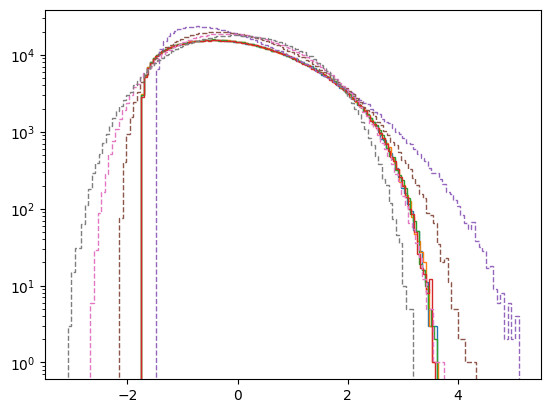

In [238]:
fig, ax = plt.subplots()

ax.hist(log_and_standardize(particles[:, 3][:,0]), bins=100, histtype='step', label='g1')
ax.hist(log_and_standardize(particles[:, 4][:,0]), bins=100, histtype='step', label='g2')
ax.hist(log_and_standardize(particles[:, 5][:,0]), bins=100, histtype='step', label='g3')
ax.hist(log_and_standardize(particles[:, 6][:,0]), bins=100, histtype='step', label='g4')
ax.hist(log_and_standardize(particles_sorted[:, 3][:,0]), bins=100, ls='--', histtype='step', label='g1')
ax.hist(log_and_standardize(particles_sorted[:, 4][:,0]), bins=100, ls='--', histtype='step', label='g2')
ax.hist(log_and_standardize(particles_sorted[:, 5][:,0]), bins=100, ls='--', histtype='step', label='g3')
ax.hist(log_and_standardize(particles_sorted[:, 6][:,0]), bins=100, ls='--', histtype='step', label='g4')

ax.set_yscale('log')
fig.show()

# qq -> Z gg

In [242]:
g1, g2 = sp.symbols('g1 g2')
q1, q2 = sp.symbols('q1 q2')
z = sp.symbols('z')

g_vars = [g1, g2]
q_vars = [q1, q2]

gg = form_SPs(g_vars)
qq = form_SPs(q_vars)
gq = form_SPs(g_vars, q_vars)
gz = form_SPs(g_vars, [z])
qz = form_SPs(q_vars, [z])

gg_invs = perm_invariants(gg)
qq_invs = perm_invariants(qq)
gq_invs = perm_invariants(gq)
gz_invs = perm_invariants(gz)
qz_invs = perm_invariants(qz)

print(gg_invs)
print(qq_invs)
print(gq_invs)
print(gz_invs)
print(qz_invs)

[g1g2]
[q1q2]
[g1q1 + g1q2 + g2q1 + g2q2, g1q1*g1q2 + g1q1*g2q1 + g1q1*g2q2 + g1q2*g2q1 + g1q2*g2q2 + g2q1*g2q2, g1q1*g1q2*g2q1 + g1q1*g1q2*g2q2 + g1q1*g2q1*g2q2 + g1q2*g2q1*g2q2, g1q1*g1q2*g2q1*g2q2]
[g1z + g2z, g1z*g2z]
[q1z + q2z, q1z*q2z]


In [245]:
zgg_data = np.load('zgg.npy')

amp = zgg_data[:, -1]
particles = zgg_data[:, :-1]
particles = particles.reshape(particles.shape[0], -1, 4)

q1s = particles[:, 0, :]
q2s = particles[:, 1, :]
zs = particles[:, 2, :]
g1s = particles[:, 3, :]
g2s = particles[:, 4, :]

gluons = np.stack([g1s, g2s], axis=1)
sorted_indices = np.argsort(gluons[:, :, 0])
gluons_sorted = np.take_along_axis(gluons, sorted_indices[:, :, np.newaxis], axis=1)

quarks = np.stack([q1s, q2s], axis=1)
sorted_indices = np.argsort(quarks[:, :, 0])
quarks_sorted = np.take_along_axis(quarks, sorted_indices[:, :, np.newaxis], axis=1)

g1s, g2s = gluons_sorted[:, 0, :], gluons_sorted[:, 1, :]
q1s, q2s = quarks_sorted[:, 0, :], quarks_sorted[:, 1, :]

q1q2s = np.array([calc_SP(q1, q2) for q1, q2 in zip(q1s, q2s)])
q1zs = np.array([calc_SP(q1, z) for q1, z in zip(q1s, zs)])
q2zs = np.array([calc_SP(q2, z) for q2, z in zip(q2s, zs)])
g1g2s = np.array([calc_SP(g1, g2) for g1, g2 in zip(g1s, g2s)])
g1zs = np.array([calc_SP(g1, z) for g1, z in zip(g1s, zs)])
g2zs = np.array([calc_SP(g2, z) for g2, z in zip(g2s, zs)])
g1q1s = np.array([calc_SP(g1, q1) for g1, q1 in zip(g1s, q1s)])
g1q2s = np.array([calc_SP(g1, q2) for g1, q2 in zip(g1s, q2s)])
g2q1s = np.array([calc_SP(g2, q1) for g2, q1 in zip(g2s, q1s)])
g2q2s = np.array([calc_SP(g2, q2) for g2, q2 in zip(g2s, q2s)])

In [247]:
gg_invs_f = lambdify(gg, gg_invs, 'numpy')
qq_invs_f = lambdify(qq, qq_invs, 'numpy')
gq_invs_f = lambdify(gq, gq_invs, 'numpy')
gz_invs_f = lambdify(gz, gz_invs, 'numpy')
qz_invs_f = lambdify(qz, qz_invs, 'numpy')

def calc_gg_invs(g1g2):
    return np.array(gg_invs_f(g1g2))

def calc_qq_invs(q1q2):
    return np.array(qq_invs_f(q1q2))

def calc_gq_invs(g1q1, g1q2, g2q1, g2q2):
    return np.array(gq_invs_f(g1q1, g1q2, g2q1, g2q2))

def calc_gz_invs(g1z, g2z):
    return np.array(gz_invs_f(g1z, g2z))

def calc_qz_invs(q1z, q2z):
    return np.array(qz_invs_f(q1z, q2z))

gg_invs_num = calc_gg_invs(g1g2s).transpose()
qq_invs_num = calc_qq_invs(q1q2s).transpose()
gq_invs_num = calc_gq_invs(g1q1s, g1q2s, g2q1s, g2q2s).transpose()
gz_invs_num = calc_gz_invs(g1zs, g2zs).transpose()
qz_invs_num = calc_qz_invs(q1zs, q2zs).transpose()

# print(qz_invs_num.mean(axis=0))
# gq_invs_num[:, 3] = gq_invs_num[:, 3]/gg_invs_num[:,0] #/gq_invs_num[:, 2] 
# gq_invs_num[:, 2] = gq_invs_num[:, 2]/gg_invs_num[:,0] #/gq_invs_num[:, 1] 
# gq_invs_num[:, 1] = gq_invs_num[:, 1]/gg_invs_num[:,0] #/gq_invs_num[:, 0] 
# gz_invs_num[:, 1] = gz_invs_num[:, 1]/gg_invs_num[:,0] #/gz_invs_num[:, 0]
# qz_invs_num[:, 1] = qz_invs_num[:, 1]/gg_invs_num[:,0] #/qz_invs_num[:, 0]
# print(qz_invs_num.mean(axis=0))

In [249]:
from sklearn.decomposition import PCA
pca = PCA()

# zgg_pinv_data = np.concatenate([gg_invs_num, qq_invs_num, gq_invs_num], axis=1)
zgg_pinv_data = np.concatenate([gg_invs_num, qq_invs_num, gq_invs_num, gz_invs_num, qz_invs_num], axis=1)
zgg_pinv_data = log_and_standardize(zgg_pinv_data)
# zgg_pinv_data = pca.fit_transform(zgg_pinv_data)
# zgg_pinv_data = np.concatenate([zgg_pinv_data, test_amp.reshape(-1, 1), prod.reshape(-1, 1)], axis=1)
zgg_pinv_data = np.concatenate([zgg_pinv_data, amp.reshape(-1, 1)], axis=1)
np.save('zgg_pinv.npy', zgg_pinv_data)

zgg_inv_data = np.concatenate([
    g1g2s.reshape(-1, 1),
    q1q2s.reshape(-1, 1),
    g1q1s.reshape(-1, 1),
    g1q2s.reshape(-1, 1),
    g2q1s.reshape(-1, 1),
    g2q2s.reshape(-1, 1),
    g1zs.reshape(-1, 1),
    g2zs.reshape(-1, 1),
    q1zs.reshape(-1, 1),
    q2zs.reshape(-1, 1)
], axis=1)
# zgg_inv_data = np.concatenate([log_and_standardize(zgg_inv_data), test_amp.reshape(-1, 1), prod.reshape(-1, 1)], axis=1)
zgg_inv_data = np.concatenate([log_and_standardize(zgg_inv_data), amp.reshape(-1, 1)], axis=1)
np.save('zgg_inv.npy', zgg_inv_data)

zgg_inv_all_data = np.concatenate([
    g1g2s.reshape(-1, 1),
    q1q2s.reshape(-1, 1),
    g1q1s.reshape(-1, 1),
    g1q2s.reshape(-1, 1),
    g2q1s.reshape(-1, 1),
    g2q2s.reshape(-1, 1),
    g1zs.reshape(-1, 1),
    g2zs.reshape(-1, 1),
    q1zs.reshape(-1, 1),
    q2zs.reshape(-1, 1),
    gg_invs_num,
    qq_invs_num,
    gq_invs_num,
    gz_invs_num,
    qz_invs_num
], axis=1)
zgg_inv_all_data = np.concatenate([log_and_standardize(zgg_inv_all_data), amp.reshape(-1, 1)], axis=1)
np.save('zgg_inv_all.npy', zgg_inv_all_data)

In [7]:
# PCA
from sklearn.decomposition import PCA
pca = PCA()

In [12]:
zgg_pinv_data = np.concatenate([gg_invs_num, qq_invs_num, gq_invs_num], axis=1)
zgg_pinv_data = np.concatenate([log_and_standardize(zgg_pinv_data)], axis=1)
trans = pca.fit_transform(zgg_pinv_data)

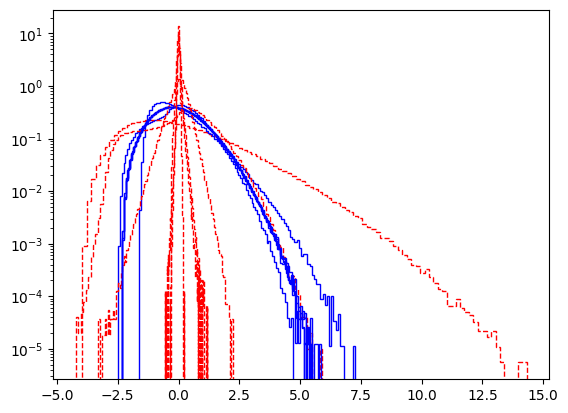

In [16]:
for i in range(6):
    plt.hist(zgg_inv_data[:, i], bins=100, color='b', histtype='step', label='zgg', density=True)
    plt.hist(zgg_pinv_data[:, i], bins=100, color='r', ls='--', histtype='step', label='zgg', density=True)
    # plt.hist(trans[:, i], bins=100, color='orange', ls='-.', histtype='step', label='zgg', density=True)
# plt.hist(zgg_pinv_data[:, 2], bins=100, color='orange', ls='--', histtype='step', label='zgg', density=True)
# plt.hist(zgg_pinv_data[:, 3], bins=100, color='orange', ls='--', histtype='step', label='zgg', density=True)
plt.yscale('log')

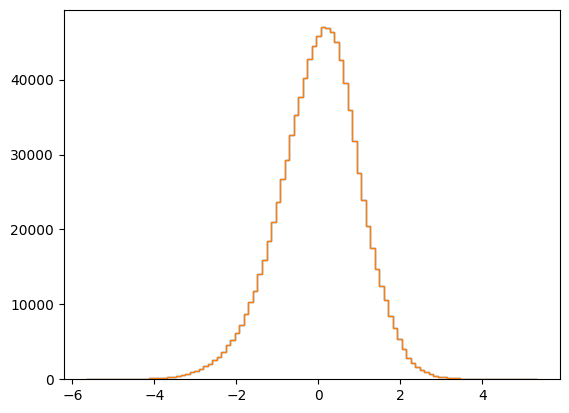

In [244]:
fig, ax = plt.subplots()

x = zgg_inv_data[:, -1]
y = x**0.3

# ax.hist(x, bins=100, histtype='step', label='zgg')
# ax.hist(np.log(x), bins=100, histtype='step', label='zgg')
ax.hist((np.log(x) - np.mean(np.log(x)))/np.std(np.log(x)), bins=100, histtype='step', label='zgg')
ax.hist((np.log(y) - np.mean(np.log(y)))/np.std(np.log(y)), bins=100, histtype='step', label='zgg')

plt.show()

# gg -> aag

In [4]:
g1, g2, g3 = sp.symbols('g1 g2 g3')
ga1, ga2 = sp.symbols('ga1 ga2')

g_vars  = [g1, g2, g3]
ga_vars = [ga1, ga2]

gg   = form_SPs(g_vars)
gaga = form_SPs(ga_vars)
gga  = form_SPs(g_vars, ga_vars)

gg, gaga, gga

([g1g2, g1g3, g2g3], [ga1ga2], [g1ga1, g1ga2, g2ga1, g2ga2, g3ga1, g3ga2])

In [256]:
gg_invs, gaga_invs, gga_invs = perm_invariants(gg), perm_invariants(gaga), perm_invariants(gga)
gg_invs, gaga_invs, gga_invs

([g1g2 + g1g3 + g2g3, g1g2*g1g3 + g1g2*g2g3 + g1g3*g2g3, g1g2*g1g3*g2g3],
 [ga1ga2],
 [g1ga1 + g1ga2 + g2ga1 + g2ga2 + g3ga1 + g3ga2,
  g1ga1*g1ga2 + g1ga1*g2ga1 + g1ga1*g2ga2 + g1ga1*g3ga1 + g1ga1*g3ga2 + g1ga2*g2ga1 + g1ga2*g2ga2 + g1ga2*g3ga1 + g1ga2*g3ga2 + g2ga1*g2ga2 + g2ga1*g3ga1 + g2ga1*g3ga2 + g2ga2*g3ga1 + g2ga2*g3ga2 + g3ga1*g3ga2,
  g1ga1*g1ga2*g2ga1 + g1ga1*g1ga2*g2ga2 + g1ga1*g1ga2*g3ga1 + g1ga1*g1ga2*g3ga2 + g1ga1*g2ga1*g2ga2 + g1ga1*g2ga1*g3ga1 + g1ga1*g2ga1*g3ga2 + g1ga1*g2ga2*g3ga1 + g1ga1*g2ga2*g3ga2 + g1ga1*g3ga1*g3ga2 + g1ga2*g2ga1*g2ga2 + g1ga2*g2ga1*g3ga1 + g1ga2*g2ga1*g3ga2 + g1ga2*g2ga2*g3ga1 + g1ga2*g2ga2*g3ga2 + g1ga2*g3ga1*g3ga2 + g2ga1*g2ga2*g3ga1 + g2ga1*g2ga2*g3ga2 + g2ga1*g3ga1*g3ga2 + g2ga2*g3ga1*g3ga2,
  g1ga1*g1ga2*g2ga1*g2ga2 + g1ga1*g1ga2*g2ga1*g3ga1 + g1ga1*g1ga2*g2ga1*g3ga2 + g1ga1*g1ga2*g2ga2*g3ga1 + g1ga1*g1ga2*g2ga2*g3ga2 + g1ga1*g1ga2*g3ga1*g3ga2 + g1ga1*g2ga1*g2ga2*g3ga1 + g1ga1*g2ga1*g2ga2*g3ga2 + g1ga1*g2ga1*g3ga1*g3ga2 + g1ga1*g2ga2*g3ga1*

In [63]:
aag_data = np.load('aag.npy')

amp = aag_data[:, -1]
particles = aag_data[:, :-1]
particles = particles.reshape(particles.shape[0], -1, 4)

g1s  = particles[:, 0, :]
g2s  = particles[:, 1, :]
ga1s = particles[:, 2, :]
ga2s = particles[:, 3, :]
g3s  = particles[:, 4, :]

In [64]:
pTjets = np.array([pyl.Momentum4(*j).p_t for j in g3s])
pTa_leading = np.array([max(pyl.Momentum4(*a1).p_t, pyl.Momentum4(*a2).p_t) for a1, a2 in zip(ga1s, ga2s)])
pTa_subleading = np.array([min(pyl.Momentum4(*a1).p_t, pyl.Momentum4(*a2).p_t) for a1, a2 in zip(ga1s, ga2s)])

etajets = np.array([pyl.Momentum4(*j).eta for j in g3s])
eta_a1 = np.array([pyl.Momentum4(*a1).eta for a1 in ga1s])
eta_a2 = np.array([pyl.Momentum4(*a2).eta for a2 in ga2s])

def deltaR(p1, p2):
    return np.sqrt((p1.eta - p2.eta)**2 + (p1.phi - p2.phi)**2)

dR_a1a2 = np.array([deltaR(pyl.Momentum4(*a1), pyl.Momentum4(*a2)) for a1, a2 in zip(ga1s, ga2s)])
dR_a1j = np.array([deltaR(pyl.Momentum4(*a1), pyl.Momentum4(*j)) for a1, j in zip(ga1s, g3s)])
dR_a2j = np.array([deltaR(pyl.Momentum4(*a2), pyl.Momentum4(*j)) for a2, j in zip(ga2s, g3s)])

In [81]:
# find duplicates in np dataset

def find_duplicates(data):
    return np.unique(data, return_counts=True)

unique, counts = find_duplicates(aag_data)

In [82]:
counts

array([  1,   1,   1, ...,   1,   1, 120])

In [67]:
mask = (pTjets > 20) & \
       (pTa_leading > 40) & \
       (pTa_subleading > 30) & \
       (abs(etajets) < 5) & \
       (abs(eta_a1) < 2.37) & \
       (abs(eta_a2) < 2.37) & \
       (dR_a1a2 > 0.4) & \
       (dR_a1j > 0.4) & \
       (dR_a2j > 0.4)
       
agg_cutted_data = aag_data[mask]
# np.save('agg_cutted.npy', agg_cutted_data)

In [68]:
agg_cutted_data.shape, aag_data.shape

((1110251, 21), (1110267, 21))

In [186]:
gluons = np.stack([g1s, g2s, g3s], axis=1)
sorted_indices = np.argsort(gluons[:, :, 0])
gluons_sorted = np.take_along_axis(gluons, sorted_indices[:, :, np.newaxis], axis=1)

photons = np.stack([ga1s, ga2s], axis=1)
sorted_indices = np.argsort(photons[:, :, 0])
photons_sorted = np.take_along_axis(photons, sorted_indices[:, :, np.newaxis], axis=1)

g1s, g2s, g3s = gluons_sorted[:, 0, :], gluons_sorted[:, 1, :], gluons_sorted[:, 2, :]
ga1s, ga2s = photons_sorted[:, 0, :], photons_sorted[:, 1, :]

In [190]:
g1g2s = np.array([calc_SP(g1, g2) for g1, g2 in zip(g1s, g2s)])
g1g3s = np.array([calc_SP(g1, g3) for g1, g3 in zip(g1s, g3s)])
g2g3s = np.array([calc_SP(g2, g3) for g2, g3 in zip(g2s, g3s)])

ga1ga2s = np.array([calc_SP(ga1, ga2) for ga1, ga2 in zip(ga1s, ga2s)])

g1ga1s = np.array([calc_SP(g1, ga1) for g1, ga1 in zip(g1s, ga1s)])
g1ga2s = np.array([calc_SP(g1, ga2) for g1, ga2 in zip(g1s, ga2s)])
g2ga1s = np.array([calc_SP(g2, ga1) for g2, ga1 in zip(g2s, ga1s)])
g2ga2s = np.array([calc_SP(g2, ga2) for g2, ga2 in zip(g2s, ga2s)])
g3ga1s = np.array([calc_SP(g3, ga1) for g3, ga1 in zip(g3s, ga1s)])
g3ga2s = np.array([calc_SP(g3, ga2) for g3, ga2 in zip(g3s, ga2s)])

In [191]:
gg_invs_f   = lambdify(gg,     gg_invs, 'numpy')
gaga_invs_f = lambdify(gaga, gaga_invs, 'numpy')
gga_invs_f  = lambdify(gga,   gga_invs, 'numpy')

def calc_gg_invs(g1g2, g1g3, g2g3):
    return np.array(gg_invs_f(g1g2, g1g3, g2g3))

def calc_gaga_invs(ga1ga2):
    return np.array(gaga_invs_f(ga1ga2))

def calc_gga_invs(g1ga1, g1ga2, g2ga1, g2ga2, g3ga1, g3ga2):
    return np.array(gga_invs_f(g1ga1, g1ga2, g2ga1, g2ga2, g3ga1, g3ga2))


gg_invs_num = calc_gg_invs(g1g2s, g1g3s, g2g3s).transpose()
gaga_invs_num = calc_gaga_invs(ga1ga2s).transpose()
gga_invs_num = calc_gga_invs(g1ga1s, g1ga2s, g2ga1s, g2ga2s, g3ga1s, g3ga2s).transpose()

# print("gg", gg_invs_num.mean(axis=0))
# gg_invs_num[:, 2] = gg_invs_num[:, 2]**(1/3)
# gg_invs_num[:, 1] = gg_invs_num[:, 2]**(1/2)
# print("gg", gg_invs_num.mean(axis=0))

# print("gga", gga_invs_num.mean(axis=0))
# gga_invs_num[:, 5] = gga_invs_num[:, 5]**(1/6)
# gga_invs_num[:, 4] = gga_invs_num[:, 4]**(1/5)
# gga_invs_num[:, 3] = gga_invs_num[:, 3]**(1/4)
# gga_invs_num[:, 2] = gga_invs_num[:, 2]**(1/3)
# gga_invs_num[:, 1] = gga_invs_num[:, 1]**(1/2)
# print("gga", gga_invs_num.mean(axis=0))


In [152]:
gg_invs

[g1g2 + g1g3 + g2g3, g1g2*g1g3 + g1g2*g2g3 + g1g3*g2g3, g1g2*g1g3*g2g3]

In [157]:
g1g2s[-1]*g1g3s[-1]*g2g3s[-1]

np.float64(3636025511161.019)

In [156]:
gg_invs_num

array([[9.28053693e+05, 2.59617208e+11, 2.27951807e+16],
       [1.87578649e+04, 8.03099044e+07, 5.07184273e+10],
       [1.04010533e+04, 2.31500687e+07, 1.18403236e+10],
       ...,
       [1.67374591e+04, 6.74146500e+07, 2.70690228e+10],
       [2.05157571e+04, 1.09500367e+08, 1.49084449e+11],
       [6.60117313e+04, 9.62251390e+08, 3.63602551e+12]])

In [192]:
aag_inv_data = np.concatenate(
    [gg_invs_num, gaga_invs_num, gga_invs_num], axis=1)
aag_inv_data = np.log(aag_inv_data)
means, stds = np.mean(aag_inv_data, axis=0), np.std(aag_inv_data, axis=0)
aag_inv_scaled_data = (aag_inv_data - means) / stds

aag_inv_naiv_data = np.concatenate([
    g1g2s[:, np.newaxis], 
    g1g3s[:, np.newaxis], 
    g2g3s[:, np.newaxis], 
    ga1ga2s[:, np.newaxis], 
    g1ga1s[:, np.newaxis], 
    g1ga2s[:, np.newaxis], 
    g2ga1s[:, np.newaxis], 
    g2ga2s[:, np.newaxis], 
    g3ga1s[:, np.newaxis], 
    g3ga2s[:, np.newaxis]
], axis=1)
aag_inv_naiv_data = np.log(aag_inv_naiv_data)
means, stds = np.mean(aag_inv_naiv_data, axis=0), np.std(aag_inv_naiv_data, axis=0)
aag_inv_naiv_scaled_data = (aag_inv_naiv_data - means) / stds
# aag_inv_data = np.concatenate([gg_invs_num, gaga_invs_num, gga_invs_num, amp[:, np.newaxis]], axis=1)

In [158]:
aag_inv_all = np.concatenate([aag_inv_scaled_data, aag_inv_naiv_scaled_data, amp[:, np.newaxis]], axis=1)

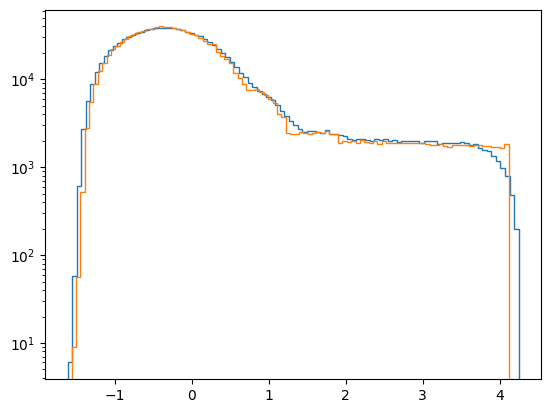

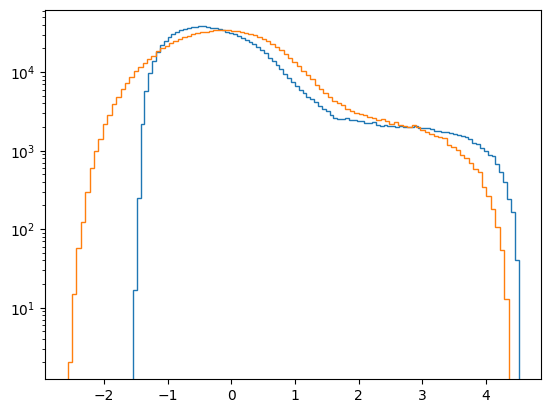

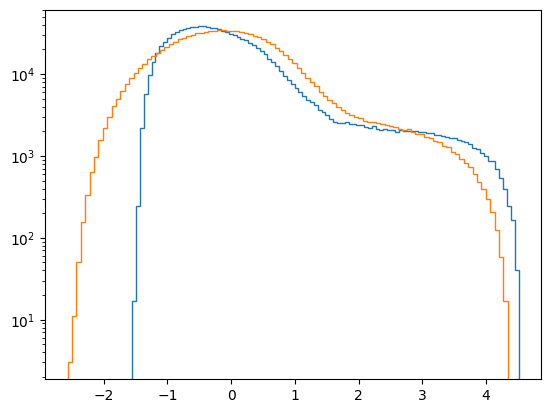

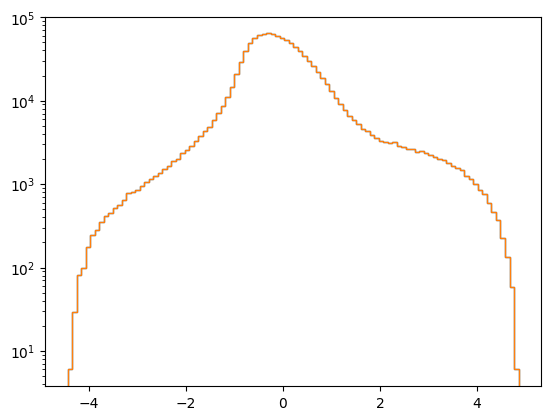

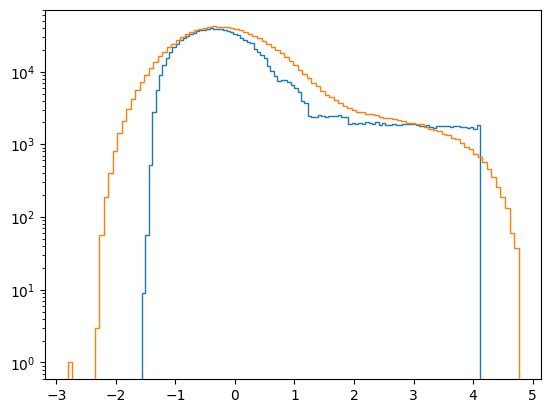

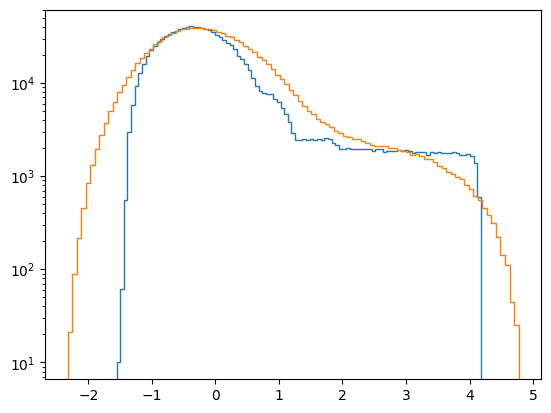

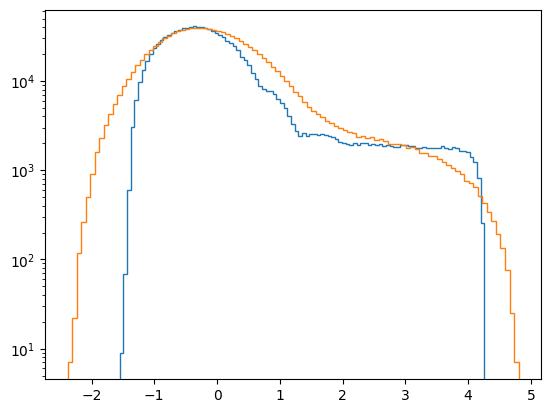

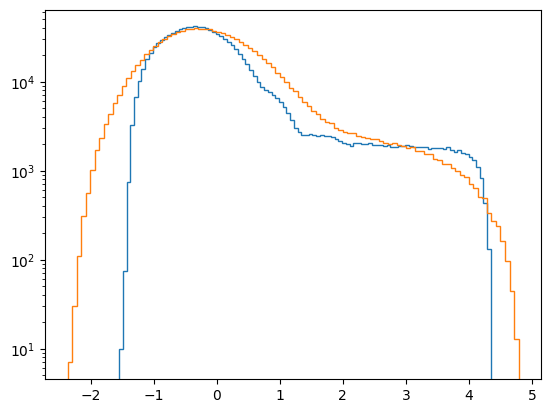

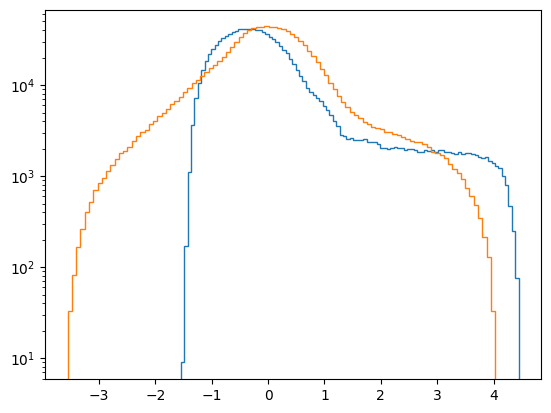

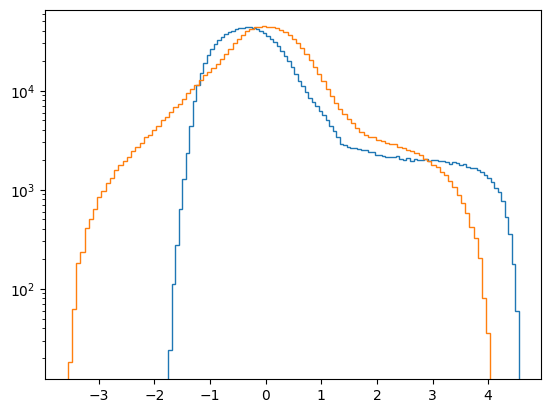

In [145]:
bins=100

invs = gg_invs + gaga_invs + gga_invs
for i in range(aag_inv_data.shape[1]):
    fig, ax = plt.subplots()

    plt.hist(aag_inv_scaled_data[:,i], bins=bins, histtype='step', label='g1g2')
    plt.hist(aag_inv_naiv_scaled_data[:,i], bins=bins, histtype='step', label='naiv')
    # ax.set_xscale('log')
    ax.set_yscale('log')
    # ax.set_title(invs[i],fontsize=4)

    plt.show()

In [146]:
aag_inv_outdata = np.concatenate([aag_inv_scaled_data, amp[:, np.newaxis]], axis=1)
aag_inv_naiv_outdata = np.concatenate([aag_inv_naiv_scaled_data, amp[:, np.newaxis]], axis=1)

In [147]:
aag_inv_outdata.mean(axis=0), aag_inv_outdata.std(axis=0)

(array([-4.11906885e-15, -6.01403379e-15, -6.01271544e-15, -8.57057252e-16,
         7.80167498e-15, -2.29872495e-15, -4.58490639e-15, -3.39826540e-16,
         5.31367113e-15,  2.89601329e-16,  7.10653731e-07]),
 array([1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
        1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
        1.00000000e+00, 1.00000000e+00, 2.17542276e-06]))

In [148]:
aag_inv_naiv_outdata.mean(axis=0), aag_inv_naiv_outdata.std(axis=0)

(array([ 3.76500548e-13,  1.12187958e-13, -1.53370079e-13, -1.44240637e-14,
         3.80077393e-13, -5.73788277e-13,  1.33675970e-13,  2.06507765e-13,
         1.20271602e-13,  1.44554705e-13,  7.10653731e-07]),
 array([1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
        1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
        1.00000000e+00, 1.00000000e+00, 2.17542276e-06]))

In [193]:
np.save('aag_inv.npy', aag_inv_outdata)
np.save('aag_inv_naiv.npy', aag_inv_naiv_outdata)
np.save('aag_inv_all.npy', aag_inv_all)